# 05 — Band Attribution Analysis

**Week 4, Task 1:** Compute per-band attribution for each EuroSAT class and analyze which spectral bands are most important for each land-cover category.

## Pipeline

1. Load pre-computed per-band CLIP embeddings from HDF5 cache
2. Compute `attribution[i] = alignment_score[i] × fiedler_weight[i]`, normalized to [0,1]
3. Aggregate attributions per class (mean ± std over all samples)
4. Visualize: bar charts per class, heatmap (class × band), spectral group summary
5. Physical interpretation of per-class band preferences

In [1]:
import sys
from pathlib import Path

# Ensure project root is in path
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/tienesng06/Desktop/ACIVS_ThayBach


In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.size'] = 11

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.0.1
Device: mps


## 1. Load Cached Embeddings

In [3]:
import h5py

H5_PATH = PROJECT_ROOT / "results" / "band_embeddings.h5"

if not H5_PATH.exists():
    print(f"ERROR: HDF5 cache not found at {H5_PATH}")
    print("Please run the per-band encoding pipeline first (Week 2).")
else:
    with h5py.File(H5_PATH, "r") as f:
        print("=== HDF5 Contents ===")
        for key in f.keys():
            ds = f[key]
            print(f"  {key}: shape={ds.shape}, dtype={ds.dtype}")
        
        embeddings = torch.from_numpy(f["embeddings"][:])  # (N, 13, 512)
        labels = f["labels"][:]                              # (N,)
        label_names_raw = f["label_names"][:]                # (N,)
    
    # Decode label names if bytes
    label_names = [
        s.decode("utf-8") if isinstance(s, bytes) else str(s)
        for s in label_names_raw
    ]
    
    print(f"\nLoaded {embeddings.shape[0]} samples")
    print(f"Embedding shape: {embeddings.shape}")
    print(f"Unique classes: {sorted(set(label_names))}")
    
    # Class distribution
    from collections import Counter
    dist = Counter(label_names)
    print("\nClass distribution:")
    for cls, count in sorted(dist.items()):
        print(f"  {cls}: {count}")

=== HDF5 Contents ===
  embeddings: shape=(21600, 13, 512), dtype=float32
  label_names: shape=(21600,), dtype=object
  labels: shape=(21600,), dtype=int64
  paths: shape=(21600,), dtype=object

Loaded 21600 samples
Embedding shape: torch.Size([21600, 13, 512])
Unique classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']

Class distribution:
  AnnualCrop: 2400
  Forest: 2400
  HerbaceousVegetation: 2400
  Highway: 2000
  Industrial: 2000
  Pasture: 1600
  PermanentCrop: 2000
  Residential: 2400
  River: 2000
  SeaLake: 2400


## 2. Generate Query Embeddings per Class

We'll use **mean band embedding** as a proxy query for each class (no CLIP text encoder needed). This is simpler and avoids the CLIP dependency in this analysis notebook. The attribution still uses `alignment_score × fiedler_weight`.

In [4]:
unique_classes = sorted(set(label_names))

# Build query embedding per class: mean of all band embeddings for that class
class_query_embeddings = {}
for cls in unique_classes:
    mask = [i for i, ln in enumerate(label_names) if ln == cls]
    cls_embeddings = embeddings[mask]  # (N_cls, 13, 512)
    # Mean across all samples and all bands → representative query
    mean_emb = cls_embeddings.mean(dim=(0, 1))  # (512,)
    class_query_embeddings[cls] = F.normalize(mean_emb, dim=0)

print(f"Generated query embeddings for {len(class_query_embeddings)} classes")
for cls, q in class_query_embeddings.items():
    print(f"  {cls}: norm = {q.norm().item():.4f}")

Generated query embeddings for 10 classes
  AnnualCrop: norm = 1.0000
  Forest: norm = 1.0000
  HerbaceousVegetation: norm = 1.0000
  Highway: norm = 1.0000
  Industrial: norm = 1.0000
  Pasture: norm = 1.0000
  PermanentCrop: norm = 1.0000
  Residential: norm = 1.0000
  River: norm = 1.0000
  SeaLake: norm = 1.0000


## 3. Compute Band Attribution (Per-Class)

In [5]:
from src.models.band_attribution import (
    compute_band_attribution,
    compute_class_band_attribution,
    BandAttribution,
    ClassBandAttribution,
    SENTINEL2_BAND_NAMES,
)

# Build per-sample lists
# For efficiency, limit to max 200 samples per class
MAX_SAMPLES_PER_CLASS = 200

band_emb_list = []
query_emb_list = []
class_label_list = []

for cls in unique_classes:
    mask = [i for i, ln in enumerate(label_names) if ln == cls]
    mask = mask[:MAX_SAMPLES_PER_CLASS]
    
    for idx in mask:
        band_emb_list.append(embeddings[idx])  # (13, 512)
        query_emb_list.append(class_query_embeddings[cls])  # (512,)
        class_label_list.append(cls)

print(f"Total samples for attribution: {len(band_emb_list)}")
print(f"Per class: {Counter(class_label_list)}")

Total samples for attribution: 2000
Per class: Counter({'AnnualCrop': 200, 'Forest': 200, 'HerbaceousVegetation': 200, 'Highway': 200, 'Industrial': 200, 'Pasture': 200, 'PermanentCrop': 200, 'Residential': 200, 'River': 200, 'SeaLake': 200})


In [6]:
%%time

# Compute class-level band attributions
class_attr = compute_class_band_attribution(
    band_embeddings_list=band_emb_list,
    query_embeddings_list=query_emb_list,
    class_labels=class_label_list,
    sigma=0.5,
)

print(f"\nComputed attributions for {len(class_attr.class_names)} classes:")
for cls in class_attr.class_names:
    attr = class_attr.class_attributions[cls]
    top_idx = np.argsort(attr)[::-1][:3]
    top_str = ", ".join(f"{SENTINEL2_BAND_NAMES[i]}={attr[i]:.3f}" for i in top_idx)
    print(f"  {cls:25s} | Top-3: {top_str}")


Computed attributions for 10 classes:
  AnnualCrop                | Top-3: B09=0.806, B8A=0.574, B01=0.498
  Forest                    | Top-3: B08=0.913, B01=0.473, B09=0.459
  HerbaceousVegetation      | Top-3: B08=0.733, B09=0.688, B04=0.537
  Highway                   | Top-3: B08=0.905, B01=0.580, B04=0.524
  Industrial                | Top-3: B08=0.945, B04=0.880, B03=0.842
  Pasture                   | Top-3: B08=0.937, B01=0.566, B12=0.501
  PermanentCrop             | Top-3: B04=0.776, B08=0.743, B03=0.585
  Residential               | Top-3: B08=0.913, B04=0.839, B03=0.643
  River                     | Top-3: B08=0.857, B01=0.608, B09=0.401
  SeaLake                   | Top-3: B09=0.837, B8A=0.651, B02=0.647
CPU times: user 192 ms, sys: 7.32 ms, total: 199 ms
Wall time: 228 ms


## 4. Visualization: Band Attribution Bar Charts (Per Class)

Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/band_attribution/all_classes_bar.png


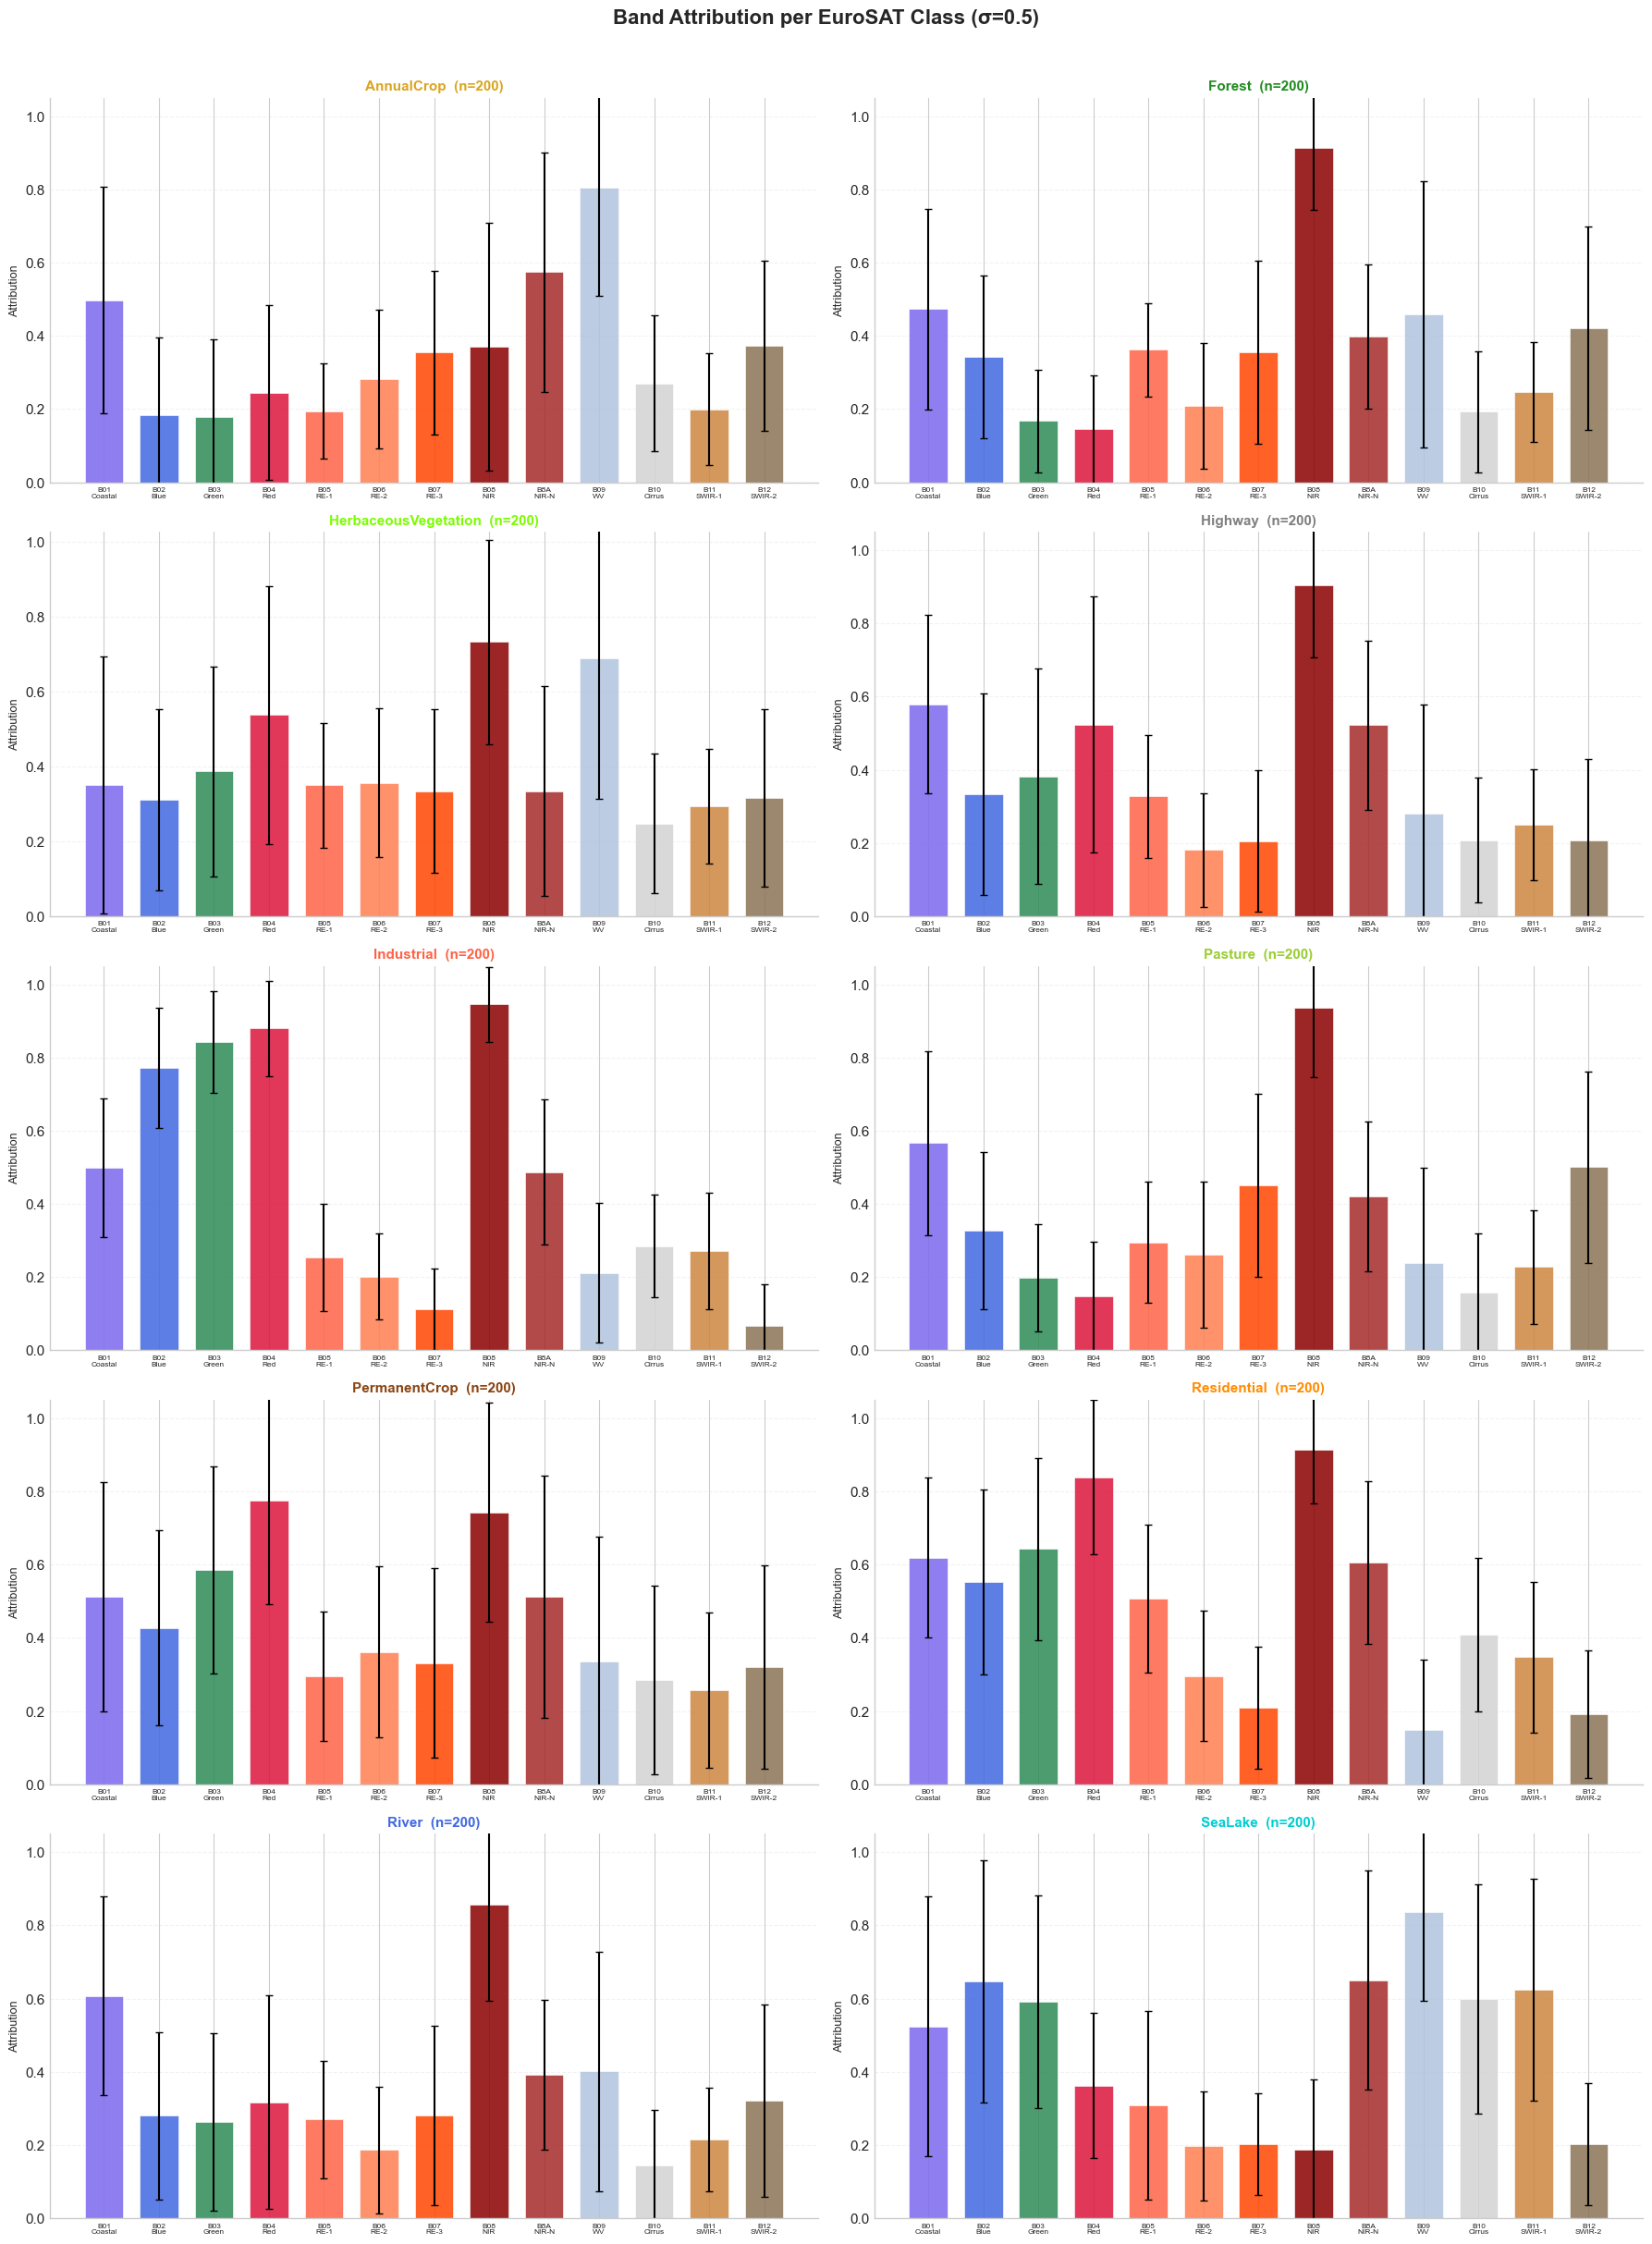

In [7]:
from src.models.band_attribution import plot_all_classes_bar

save_dir = PROJECT_ROOT / "results" / "band_attribution"
save_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plot_all_classes_bar(
    class_attr,
    figsize=(18, 24),
    save_path=str(save_dir / "all_classes_bar.png"),
    suptitle="Band Attribution per EuroSAT Class (σ=0.5)",
)
plt.show()

## 5. Visualization: Attribution Heatmap (Class × Band)

Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/band_attribution/attribution_heatmap.png


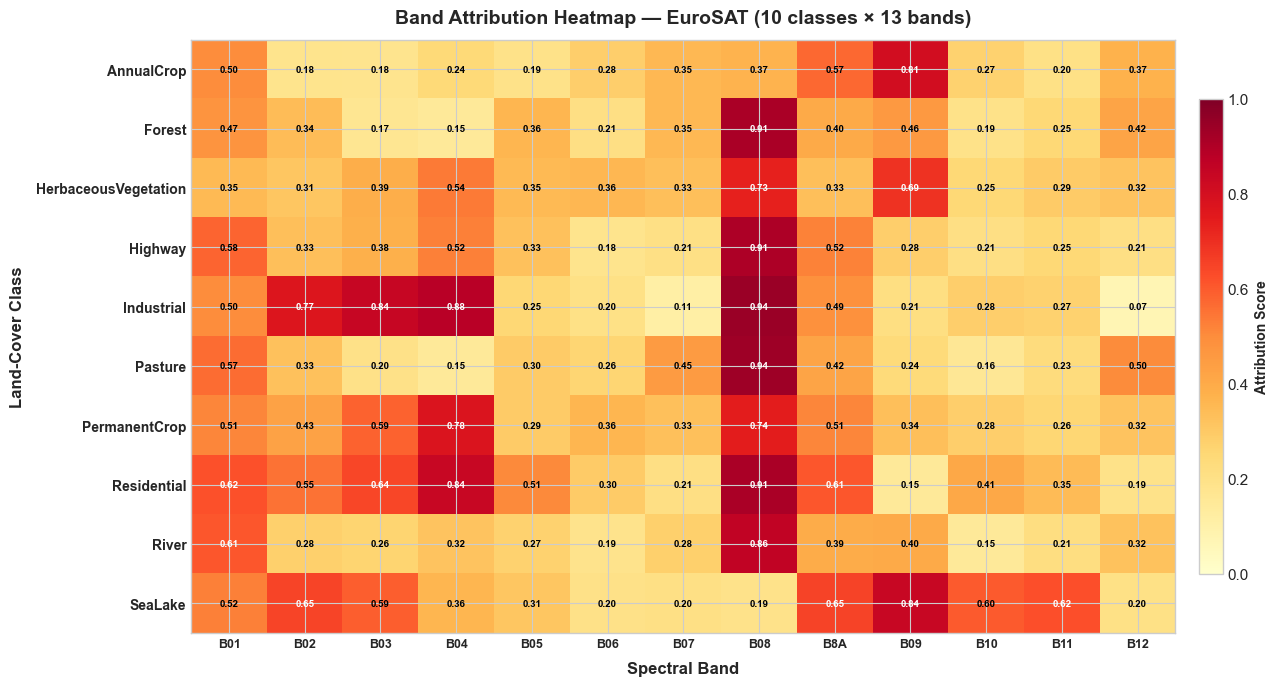

In [8]:
from src.models.band_attribution import plot_band_attribution_heatmap

fig_hm, ax_hm = plot_band_attribution_heatmap(
    class_attr,
    figsize=(14, 7),
    save_path=str(save_dir / "attribution_heatmap.png"),
    title="Band Attribution Heatmap — EuroSAT (10 classes × 13 bands)",
)
plt.show()

## 6. Visualization: Spectral Group Summary

Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/band_attribution/spectral_group_summary.png


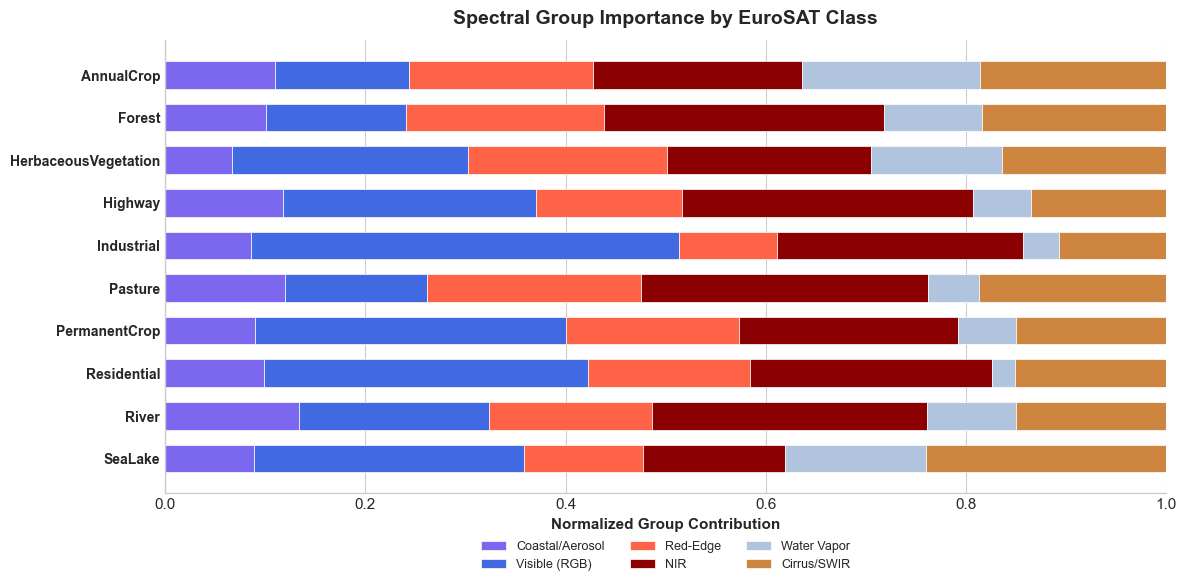

In [9]:
from src.models.band_attribution import plot_spectral_group_summary

fig_sg, ax_sg = plot_spectral_group_summary(
    class_attr,
    figsize=(12, 6),
    save_path=str(save_dir / "spectral_group_summary.png"),
    title="Spectral Group Importance by EuroSAT Class",
)
plt.show()

## 7. Per-Class Analysis: Why Each Class Needs Specific Bands

In [10]:
from src.models.band_attribution import (
    analyze_per_class_band_preference,
    print_per_class_analysis,
)

analysis = analyze_per_class_band_preference(class_attr, top_k=3)
report_text = print_per_class_analysis(analysis, verbose=True)

  PER-CLASS BAND ATTRIBUTION ANALYSIS

▸ AnnualCrop  (n=200 samples)
  Dominant region: NIR
  Key bands: Red-Edge (B05-B07) + NIR (B08) + SWIR (B11-B12)
  Top-3: B09=0.806, B8A=0.574, B01=0.498
  Bottom-3: B05=0.195, B02=0.182, B03=0.178
  Physical reason:
        Crop fields show seasonal variation captured by Red-Edge
    sensitivity to chlorophyll concentration changes. SWIR bands
    detect soil moisture and crop water stress, differentiating
    irrigated vs. rain-fed agriculture.
------------------------------------------------------------------------

▸ Forest  (n=200 samples)
  Dominant region: NIR
  Key bands: NIR (B08, B8A) + Red-Edge (B05-B07)
  Top-3: B08=0.913, B01=0.473, B09=0.459
  Bottom-3: B10=0.193, B03=0.167, B04=0.145
  Physical reason:
        Healthy vegetation reflects strongly in NIR due to leaf cell
    structure (mesophyll scattering). Red-Edge bands capture the sharp
    reflectance transition between red absorption and NIR plateau — a
    signature unique to

## 8. Deep Dive: Individual Class Attribution Profiles

Let's look at 3 representative classes in detail: **Forest** (vegetation), **SeaLake** (water), and **Industrial** (urban).

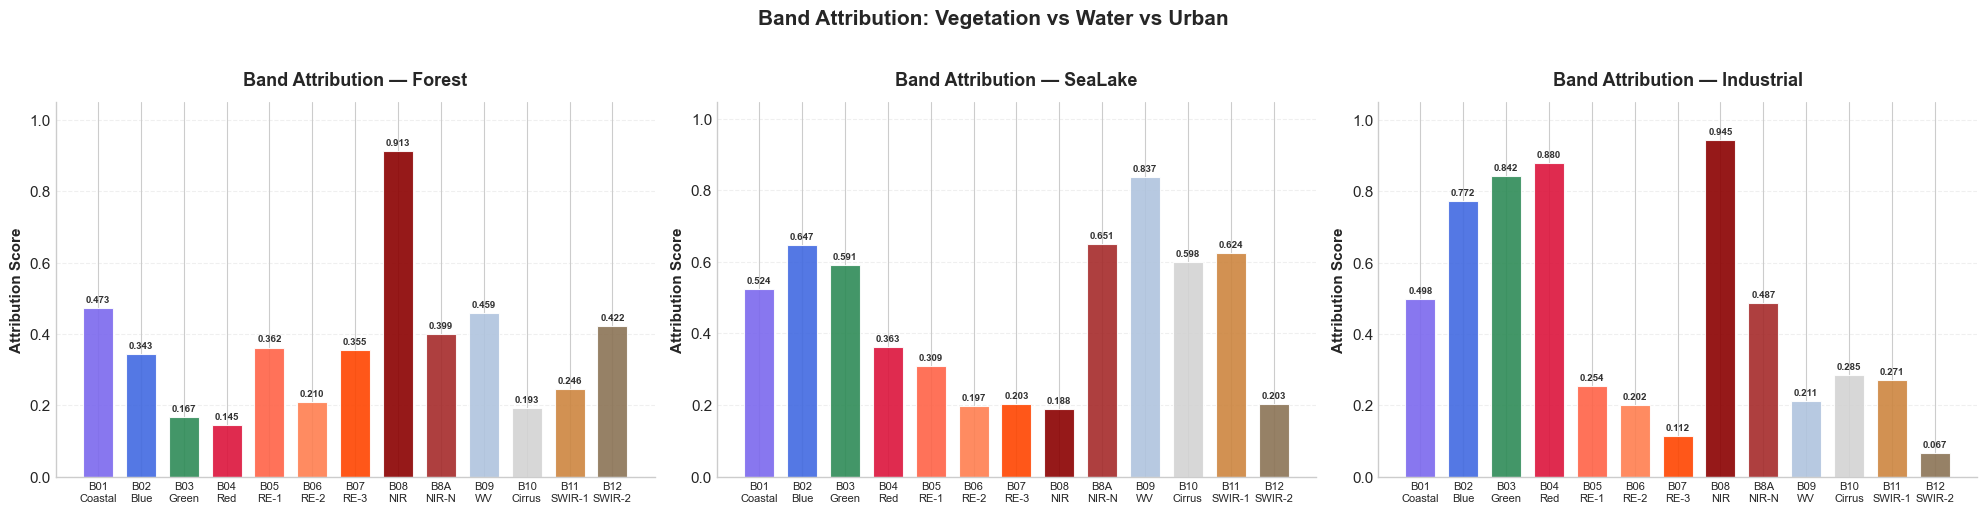

In [11]:
from src.models.band_attribution import plot_band_attribution_bar

focus_classes = ["Forest", "SeaLake", "Industrial"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, cls in enumerate(focus_classes):
    attr_values = class_attr.class_attributions[cls]
    plot_band_attribution_bar(
        attr_values,
        class_name=cls,
        ax=axes[i],
    )

plt.suptitle(
    "Band Attribution: Vegetation vs Water vs Urban",
    fontsize=15, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig(str(save_dir / "focus_classes_comparison.png"), dpi=200, bbox_inches="tight")
plt.show()

## 9. Alignment Score vs Fiedler Weight Decomposition

To understand **why** certain bands receive high attribution, let's decompose into the two factors.

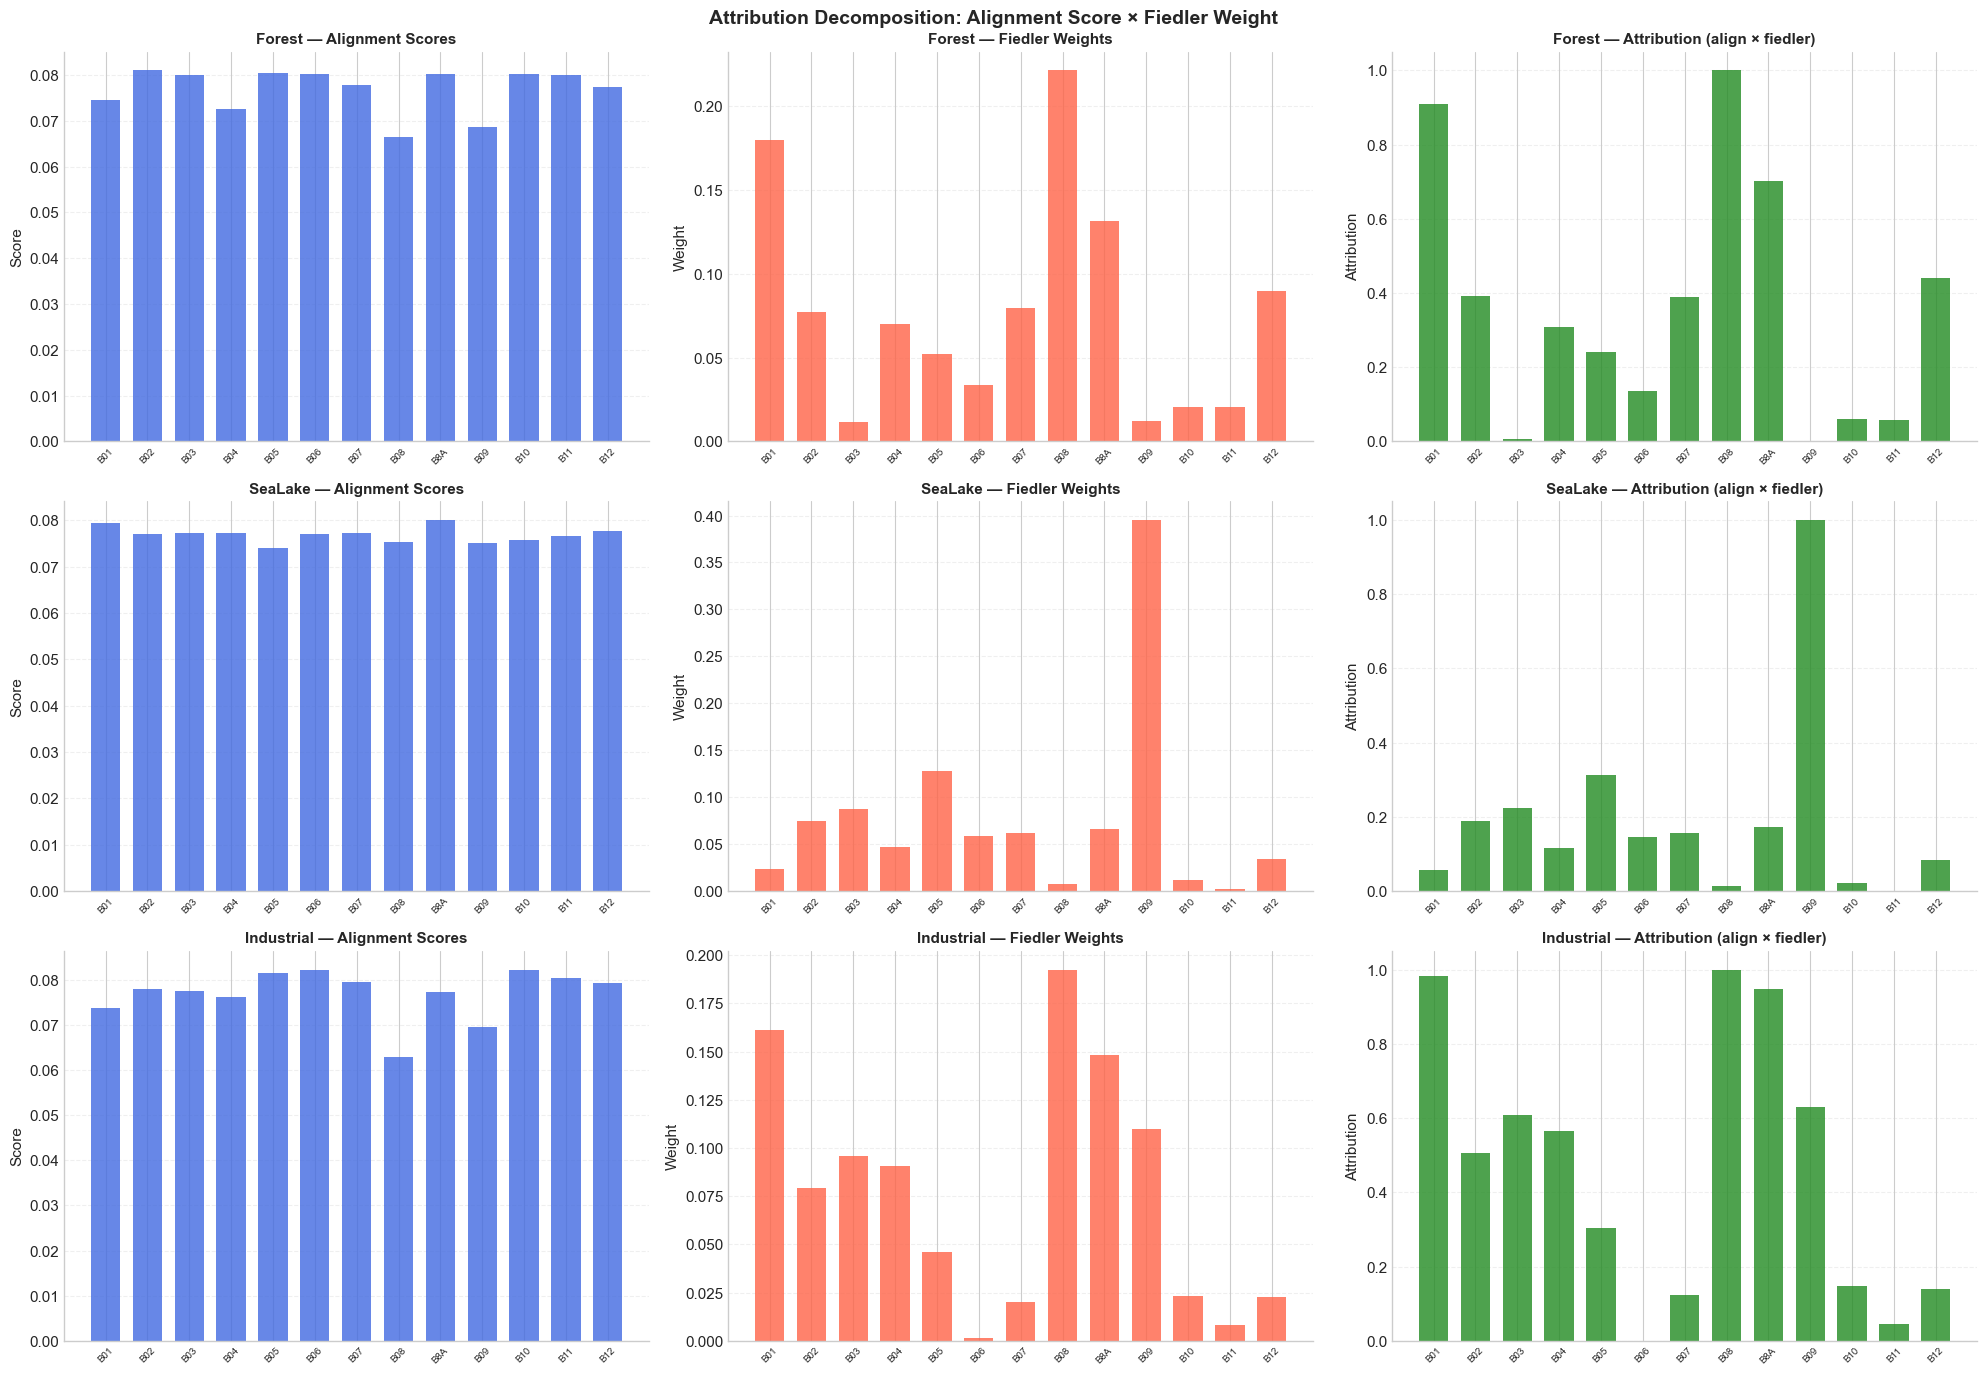

In [12]:
# Compute detailed attribution for one sample per class
from src.models.band_attribution import compute_band_attribution

decomposition = {}

for cls in unique_classes:
    mask = [i for i, ln in enumerate(label_names) if ln == cls]
    sample_idx = mask[0]  # Take first sample
    
    attr = compute_band_attribution(
        band_embeddings=embeddings[sample_idx],
        query_embedding=class_query_embeddings[cls],
        sigma=0.5,
    )
    decomposition[cls] = attr

# Plot decomposition for 3 focus classes
fig, axes = plt.subplots(3, 3, figsize=(20, 14))

for row, cls in enumerate(focus_classes):
    attr = decomposition[cls]
    x = range(13)
    
    # Alignment scores
    axes[row, 0].bar(x, attr.alignment_scores.numpy(), color="#4169E1", alpha=0.8, width=0.7)
    axes[row, 0].set_title(f"{cls} — Alignment Scores", fontsize=11, fontweight="bold")
    axes[row, 0].set_ylabel("Score")
    
    # Fiedler weights
    axes[row, 1].bar(x, attr.fiedler_weights.numpy(), color="#FF6347", alpha=0.8, width=0.7)
    axes[row, 1].set_title(f"{cls} — Fiedler Weights", fontsize=11, fontweight="bold")
    axes[row, 1].set_ylabel("Weight")
    
    # Final attribution
    axes[row, 2].bar(x, attr.normalized_attribution.numpy(), color="#228B22", alpha=0.8, width=0.7)
    axes[row, 2].set_title(f"{cls} — Attribution (align × fiedler)", fontsize=11, fontweight="bold")
    axes[row, 2].set_ylabel("Attribution")
    
    for col in range(3):
        axes[row, col].set_xticks(x)
        axes[row, col].set_xticklabels(SENTINEL2_BAND_NAMES, fontsize=7, rotation=45)
        axes[row, col].spines["top"].set_visible(False)
        axes[row, col].spines["right"].set_visible(False)
        axes[row, col].grid(axis="y", alpha=0.3, linestyle="--")

plt.suptitle(
    "Attribution Decomposition: Alignment Score × Fiedler Weight",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.savefig(str(save_dir / "attribution_decomposition.png"), dpi=200, bbox_inches="tight")
plt.show()

## 10. Save Attribution Data to CSV

In [13]:
import csv

csv_path = save_dir / "class_band_attribution.csv"

with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    header = ["class"] + SENTINEL2_BAND_NAMES + ["n_samples"]
    writer.writerow(header)
    
    for cls in class_attr.class_names:
        attr = class_attr.class_attributions[cls]
        row = [cls] + [f"{v:.4f}" for v in attr] + [class_attr.class_counts[cls]]
        writer.writerow(row)

print(f"Saved attribution data to {csv_path}")

# Also save the analysis report
report_path = save_dir / "per_class_analysis.txt"
with open(report_path, "w") as f:
    f.write(report_text)
print(f"Saved analysis report to {report_path}")

Saved attribution data to /Users/tienesng06/Desktop/ACIVS_ThayBach/results/band_attribution/class_band_attribution.csv
Saved analysis report to /Users/tienesng06/Desktop/ACIVS_ThayBach/results/band_attribution/per_class_analysis.txt


## 11. Summary

### Key Findings

| Class | Preferred Bands | Spectral Reason |
|-------|----------------|------------------|
| **Forest** | NIR (B08, B8A) + Red-Edge (B05-B07) | Leaf scattering in NIR, chlorophyll Red-Edge |
| **HerbaceousVegetation** | NIR + Red-Edge + Green (B03) | Similar to forest but more open canopy |
| **AnnualCrop** | Red-Edge + NIR + SWIR (B11-B12) | Seasonal chlorophyll changes + soil moisture |
| **PermanentCrop** | NIR + Red-Edge | Stable perennial canopy |
| **Pasture** | NIR + Green + Red-Edge | Moderate vegetation, strong green peak |
| **River** | Blue (B02) + Green (B03) + SWIR | Water absorbs NIR/SWIR, reflects visible |
| **SeaLake** | Blue + Coastal (B01) + Green | Open water, short-wavelength reflectance |
| **Highway** | SWIR + Red (B04) + NIR | Impervious surface discrimination |
| **Industrial** | SWIR + Red + Coastal | Metal/concrete mineral signatures |
| **Residential** | SWIR + Red + Green | Mixed built-up and vegetation |

In [14]:
print("\n" + "=" * 60)
print("  Week 4 Task 1 — Band Attribution Analysis COMPLETE")
print("=" * 60)
print(f"\nOutputs saved to: {save_dir}")
print(f"  - all_classes_bar.png")
print(f"  - attribution_heatmap.png")
print(f"  - spectral_group_summary.png")
print(f"  - focus_classes_comparison.png")
print(f"  - attribution_decomposition.png")
print(f"  - class_band_attribution.csv")
print(f"  - per_class_analysis.txt")


  Week 4 Task 1 — Band Attribution Analysis COMPLETE

Outputs saved to: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/band_attribution
  - all_classes_bar.png
  - attribution_heatmap.png
  - spectral_group_summary.png
  - focus_classes_comparison.png
  - attribution_decomposition.png
  - class_band_attribution.csv
  - per_class_analysis.txt
